# Discrete Time Systems

# 1. Introduction

discrete-time systems (linearity, time-invariance, causality, stability, the convolution sum, FIR/IIR systems, 
system interconnections, and difference equations).

```
                    Discrete system
        ┌────────────────┬────────────────┐
  Linear & time-      Causal           Stable
  invariant (LTI)
        │
        ├── impulse response
        ├── convolution sum
        ├── FIR
        ├── IIR
        └── difference equations
```

In what follows we consider only single-input, single-output systems:

$$x[n] \;\longrightarrow\; \boxed{T\{\cdot\}} \;\longrightarrow\; y[n]$$

**Discrete system** — any operator (algorithm, circuit) that maps the input sequence $x[n]$ into the output sequence $y[n]$.

## Examples

**Ideal delay** — a system with memory, because the output depends on a past state:

$$y[n] = x[n-2]$$

**Time-reversal property (folding)** — changing the sign of $n$ corresponds to a reflection of the values about the vertical axis:

$$y[n] = x[-n]$$

**Accumulator** — a system with memory:

$$y[n] = \sum_{k=-\infty}^{n} x[k]$$

By imposing constraints on the transformation $T\{\cdot\}$, classes of discrete-time systems can be defined.

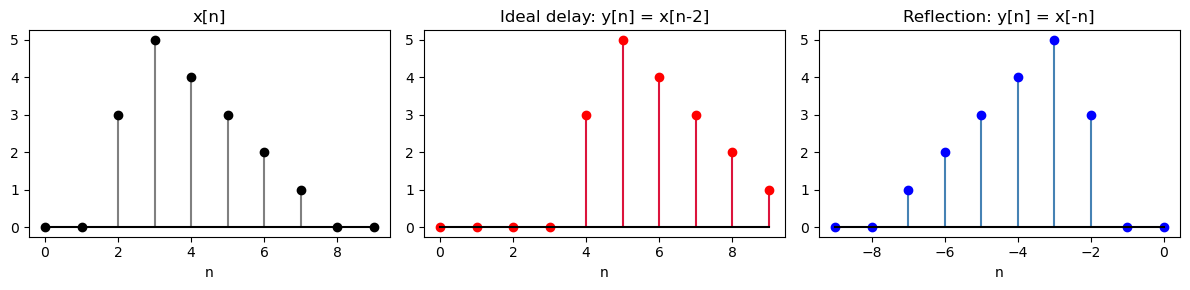

In [12]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(0, 10)
x = np.array([0,0,3,5,4,3,2,1,0,0], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(12,3))

axes[0].stem(n, x, linefmt='gray', markerfmt='ko', basefmt='black')
axes[0].set_title('x[n]')

y_delay = np.roll(x, 2); y_delay[:2] = 0
axes[1].stem(n, y_delay, linefmt='crimson', markerfmt='ro', basefmt='black')
axes[1].set_title('Ideal delay: y[n] = x[n-2]')

y_rev = x[::-1]
axes[2].stem(n - n.max(), y_rev, linefmt='steelblue', markerfmt='bo', basefmt='black')
axes[2].set_title('Reflection: y[n] = x[-n]')

for ax in axes:
    ax.set_xlabel('n')
plt.tight_layout()
plt.show()

# 2. Linear and Time-Invariant Systems (LTI)

**Linearity**

The operator $T\{\cdot\}$ is linear if and only if the superposition principle holds: if

$$y_1[n] = T\{x_1[n]\}, \qquad y_2[n] = T\{x_2[n]\}$$

then

$$a\,y_1[n] + b\,y_2[n] = T\{a\,x_1[n] + b\,x_2[n]\}$$

for any constants $a, b$ and any $x_1[n], x_2[n]$. (Note: multiple inputs are handled easily this way.)

**Time-Invariance (Stationarity)**

The operator $T\{\cdot\}$ is time-invariant if and only if the transformation it performs does not depend on the instant of application. When the index $n$ is associated with time, invariance to translation corresponds to time-invariance:

$$\text{invariance to translation} \;\Longrightarrow\; \text{time-invariance} \equiv \text{stationarity}$$

If $y[n] = T\{x[n]\}$, then

$$y[n-n_0] = T\{x[n-n_0]\} \qquad \text{for any } n_0 \text{ and } x[n]$$

# 3. Causal Systems

**Causality** — the operator $T\{\cdot\}$ is causal if its output at index $n_0$ depends only on inputs with index $k \le n_0$ (from the past and the present). 

If

$$y_1[n]=T\{x_1[n]\}, \quad y_2[n]=T\{x_2[n]\}$$

then

$$x_1[n]=x_2[n] \text{ for } n \le n_0 \;\Longrightarrow\; y_1[n]=y_2[n] \text{ for } n \le n_0$$

for any $n_0$, $x_1[n]$, $x_2[n]$. Causality is a strong constraint. Systems are classified as:
- **on-line** (causality is a required constraint)
- **off-line** (causality is not a constraint)

**Example**
- Forward difference: $y[n] = x[n+1] - x[n]$ → **not** causal
- Backward difference: $y[n] = x[n] - x[n-1]$ → causal

# 4. Stable Systems

**Stability** — the operator $T\{\cdot\}$ is said to be stable (bounded-input, bounded-output) if a bounded input always produces a bounded output. If $y[n] = T\{x[n]\}$, then

$$|x[n]| \le B_x < +\infty \;\Longrightarrow\; |y[n]| \le B_y < +\infty$$

# 5. Properties of LTI Systems — Impulse Response

If $T\{\cdot\}$ is an LTI operator, it is **completely characterized** by its response to the unit impulse.

**Impulse response:** $\;h[n] = T\{\delta[n]\}$

Then, using the sampling property and the linearity/time-invariance of $T\{\cdot\}$:

$$y[n] = T\{x[n]\} = T\left\{\sum_{k=-\infty}^{+\infty} x[k]\,\delta[n-k]\right\} = \sum_{k=-\infty}^{+\infty} x[k]\, T\{\delta[n-k]\} = \sum_{k=-\infty}^{+\infty} x[k]\, h[n-k]$$

Equivalently:

$$y[n] = \sum_{k=-\infty}^{+\infty} x[k]\,h[n-k] = \sum_{k=-\infty}^{+\infty} x[n-k]\,h[k]$$

### Convolution Sum

$$y[n] = x[n] * h[n] = h[n] * x[n]$$

The convolution sum is not a constraint, but an intrinsic characteristic of LTI systems: the output of an LTI system can always be computed as a convolution between the input and the impulse response.

#### Graphical example of convolution

Convolution = reverse one sequence, slide it over the other, multiply point-by-point, and sum.

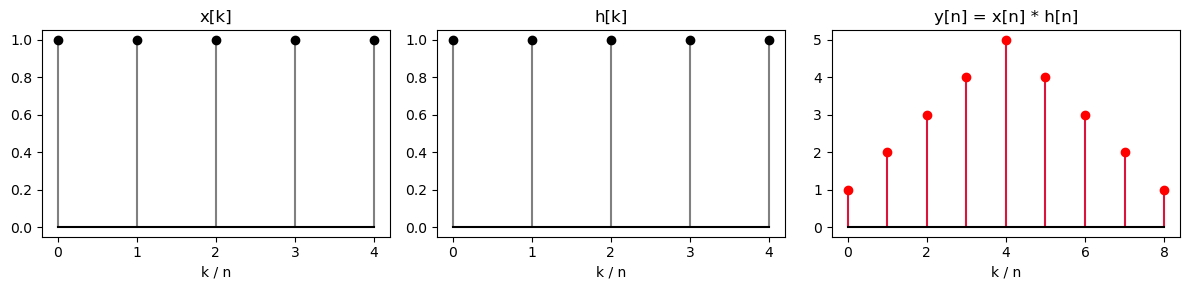

y[n] values: [1. 2. 3. 4. 5. 4. 3. 2. 1.]


In [13]:
x = np.array([1,1,1,1,1], dtype=float)   # x[k]
h = np.array([1,1,1,1,1], dtype=float)   # h[k]

y = np.convolve(x, h)
n = np.arange(len(y))

fig, axes = plt.subplots(1, 3, figsize=(12,3))
axes[0].stem(np.arange(len(x)), x, linefmt='gray', markerfmt='ko', basefmt='black')
axes[0].set_title('x[k]')
axes[1].stem(np.arange(len(h)), h, linefmt='gray', markerfmt='ko', basefmt='black')
axes[1].set_title('h[k]')
axes[2].stem(n, y, linefmt='crimson', markerfmt='ro', basefmt='black')
axes[2].set_title('y[n] = x[n] * h[n]')
for ax in axes:
    ax.set_xlabel('k / n')
plt.tight_layout()
plt.show()

print('y[n] values:', y)

### Another Fundamental Property

$$y[n] = h[n] * x[n] = x[n] * h[n]$$

The order in which the convolution between two sequences is carried out is not important: the system output is the same if the roles of the input and the impulse response are swapped.

**Important consequence**

Two LTI systems in **cascade** form a linear, time-invariant system whose impulse response is the convolution of the two individual impulse responses. Since the order of convolution does not matter:

> The impulse response of a cascade combination of linear, time-invariant systems is independent > of the order in which they are cascaded.

This is:
$$x[n] \;\longrightarrow\; \boxed{h1(n)} \;\longrightarrow\; \boxed{h2(n)} \;\longrightarrow\; y[n]$$
equivalent to this:
$$x[n] \;\longrightarrow\; \boxed{h2(n)} \;\longrightarrow\; \boxed{h1(n)} \;\longrightarrow\; y[n]$$
and to this:
$$x[n] \;\longrightarrow\; \boxed{h1(n)*h2(n)} \;\longrightarrow\; y[n]$$

### Convolution Properties

- **Commutative:** $\;h[n]*x[n] = x[n]*h[n]$
- **Distributive:** $\;h[n]*(x_1[n]+x_2[n]) = h[n]*x_1[n] + h[n]*x_2[n]$
- **Linear (scaling):** $\;h[n]*(a\,x_1[n]+b\,x_2[n]) = a\,(h[n]*x_1[n]) + b\,(h[n]*x_2[n])$

The response of a system can be computed in two equivalent ways:

1. As the superposition of the system's responses to the impulses $x[k]$, with weight $k$:

$$y[n] = \sum_{k=-\infty}^{+\infty} x[k]\cdot T\{\delta[n-k]\}$$

2. As the sum of products between the samples of $x[n]$ and the samples of the sequence $h[k]$ reversed and shifted by $n$:

$$y[n] = \sum_{k=-\infty}^{+\infty} x[k]\cdot h[-(k-n)]$$

### Impulse Response — Causal and Stable Systems

**Causal LTI systems**

An LTI system is causal if and only if its impulse response is zero for $n<0$:

$$h[n] = 0 \quad \forall n < 0$$

and then

$$y[n] = \sum_{k=0}^{+\infty} h[k]\,x[n-k]$$

**Stable LTI systems (BIBO)**

$$|y[n]| \le \sum_{k=-\infty}^{+\infty} |h[k]|\cdot|x[n-k]| \le B_x \sum_{k=-\infty}^{+\infty} |h[k]|$$

For stability to hold for any $x[n]$, it is necessary and sufficient that:

$$\sum_{k=-\infty}^{+\infty} |h[k]| < +\infty$$

# 6. Classification of LTI Systems — FIR and IIR

**FIR — Finite-duration Impulse Response**

$$h[n] \neq 0 \text{ only for } n_1 \le n \le n_2$$

A finite-duration impulse response is **always stable**, provided $|h[n]| < +\infty$ for all $n$.

**IIR — Infinite-duration Impulse Response**

An infinite-duration impulse response is stable **only if**:

$$\sum_{k=-\infty}^{+\infty} |h[k]| < +\infty$$

**Typical case 1**

$$h[n] = a^n u[n] \qquad \begin{cases} \text{stable}, & |a| < 1 \\ \text{unstable}, & |a| \ge 1 \end{cases}$$

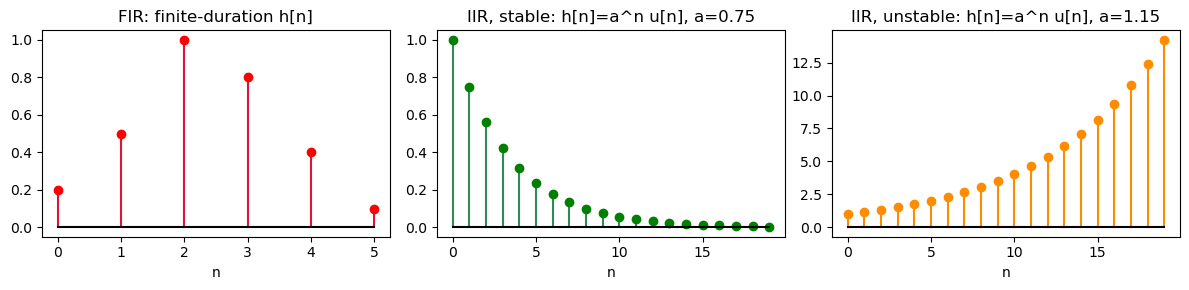

In [14]:
n = np.arange(0, 20)

fig, axes = plt.subplots(1, 3, figsize=(12,3))

n_fir = np.arange(0, 6)
h_fir = np.array([0.2, 0.5, 1.0, 0.8, 0.4, 0.1])
axes[0].stem(n_fir, h_fir, linefmt='crimson', markerfmt='ro', basefmt='black')
axes[0].set_title('FIR: finite-duration h[n]')

a_stable = 0.75
h_stable = a_stable**n
axes[1].stem(n, h_stable, linefmt='seagreen', markerfmt='go', basefmt='black')
axes[1].set_title(f'IIR, stable: h[n]=a^n u[n], a={a_stable}')

a_unstable = 1.15
h_unstable = a_unstable**n
axes[2].stem(n, h_unstable, linefmt='darkorange', markerfmt='o', basefmt='black')
axes[2].set_title(f'IIR, unstable: h[n]=a^n u[n], a={a_unstable}')

for ax in axes:
    ax.set_xlabel('n')
plt.tight_layout()
plt.show()

### Examples of LTI Systems

| System | Output relation | Impulse response | Classification |
|---|---|---|---|
| Identity | $y[n]=x[n]$ | $h[n]=\delta[n]$ | FIR, causal, stable |
| Delay by $n_0$ | $y[n]=x[n-n_0]$ | $h[n]=\delta[n-n_0]$ | FIR; causal & stable if $n_0>0$, non-causal & stable if $n_0<0$ |
| Forward difference | $y[n]=x[n+1]-x[n]$ | $h[n]=\delta[n+1]-\delta[n]$ | FIR, **not causal**, stable |
| Backward difference | $y[n]=x[n]-x[n-1]$ | $h[n]=\delta[n]-\delta[n-1]$ | FIR, causal, stable |
| Accumulator | $y[n]=\sum_{k=-\infty}^{n}x[k]$ | $h[n]=\sum_{k=-\infty}^{n}\delta[k]=u[n]$ | IIR, causal, **not stable** |
| Delayed accumulator | $y[n]=\sum_{k=-\infty}^{n}x[k-n_0]$ | $h[n]=u[n-n_0]$ | IIR, not stable; causal if $n_0>0$, not causal if $n_0<0$ |

### Interconnections of LTI Systems

LTI systems can be connected in two ways: (1) **cascade**, (2) **parallel**.

**1) Cascade**

$$x[n] \to \boxed{h_1[n]} \to z[n] \to \boxed{h_2[n]} \to y[n]$$

$$z[n] = h_1[n]*x[n], \qquad y[n] = h_2[n]*z[n] \;\Longrightarrow\; y[n] = \big(h_1[n]*h_2[n]\big)*x[n]$$

**2) Parallel**

$$y[n] = \big(h_1[n] + h_2[n]\big) * x[n]$$

**Inverse system**

A system $h'[n]$ is the **inverse** of $h[n]$ if, when connected in cascade after it,

$$y[n] = \big(h[n]*h'[n]\big)*x[n] = x[n]$$

i.e. if

$$h[n]*h'[n] = \delta[n] \;\Longrightarrow\; h'[n] \text{ is the inverse of } h[n]$$


In [15]:
# Verify: cascade order doesn't matter, and h2 = inverse of h1 gives identity
h1 = np.array([1.0, -0.5])      # e.g. a simple FIR system
h2 = np.array([1.0, 0.5, 0.25]) # an approximate 'inverse-like' system

y_order1 = np.convolve(h1, h2)
y_order2 = np.convolve(h2, h1)

print('h1 * h2 :', np.round(y_order1, 4))
print('h2 * h1 :', np.round(y_order2, 4))
print('Cascade order is irrelevant:', np.allclose(y_order1, y_order2))

h1 * h2 : [ 1.     0.     0.    -0.125]
h2 * h1 : [ 1.     0.     0.    -0.125]
Cascade order is irrelevant: True


### Worked Example: from system relation to impulse response

**System A**

$$y[n] = 3x[n] + 2x[n-1] + x[n-2]$$

Here $M=2$, $b_0=3$, $b_1=2$, $b_2=1$. Driving the system with $x[n]=\delta[n]$ (the unit impulse):

$$n=0: \; y[0]=3\delta[0]+2\delta[-1]+\delta[-2]=3=b_0$$
$$n=1: \; y[1]=3\delta[1]+2\delta[0]+\delta[-1]=2=b_1$$
$$n=2: \; y[2]=3\delta[2]+2\delta[1]+\delta[0]=1=b_2$$

The output is, naturally, the impulse response itself: $h[n] = \{3, 2, 1\}$ for $n=0,1,2$ (FIR).

**System B (recursive form)**

$$y[n] - y[n-1] = 3x[n] + 2x[n-1]$$

Here $M=1$, $b_0=3$, $b_1=2$, $N=1$, $a_0=1$, $a_1=-1$. With $x[n]=\delta[n]$, written in causal (recursive) form:

$$y[n] = y[n-1] + 3x[n] + 2x[n-1]$$

with the boundary (rest) condition $y[-1]=0$:

$$n=0: \; y[0] = y[-1] + 3\delta[0] + 2\delta[-1] = 3$$
$$n=1: \; y[1] = y[0] + 3\delta[1] + 2\delta[0] = 3 + 2 = 5$$
$$n=2: \; y[2] = y[1] + 3\delta[2] + 2\delta[1] = 5$$

This is an IIR system: the impulse response keeps a constant value of 5 once the recursion settles.


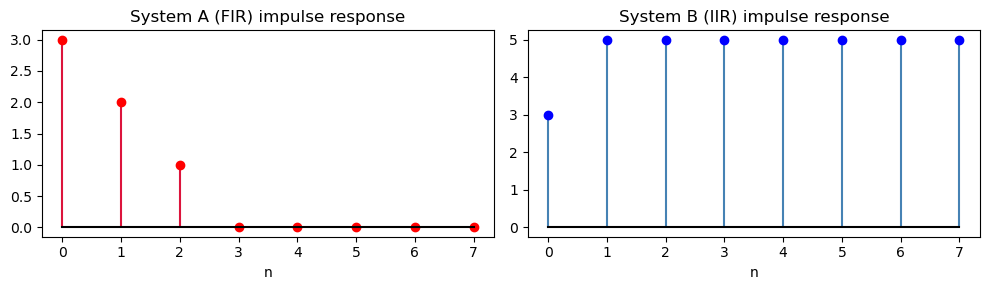

System A (FIR) h[n]: [3. 2. 1. 0. 0.]
System B (IIR) h[n]: [3. 5. 5. 5. 5.]


In [16]:
import numpy as np

# System A: FIR, y[n] = 3x[n] + 2x[n-1] + x[n-2]
N = 8
delta = np.zeros(N); delta[0] = 1
yA = np.zeros(N)
for n in range(N):
    yA[n] = 3*delta[n] + (2*delta[n-1] if n-1>=0 else 0) + (1*delta[n-2] if n-2>=0 else 0)

# System B: IIR, y[n] = y[n-1] + 3x[n] + 2x[n-1], y[-1] = 0
yB = np.zeros(N)
y_prev = 0.0
for n in range(N):
    xn = delta[n]
    xn_1 = delta[n-1] if n-1>=0 else 0
    yB[n] = y_prev + 3*xn + 2*xn_1
    y_prev = yB[n]

fig, axes = plt.subplots(1,2, figsize=(10,3))
axes[0].stem(np.arange(N), yA, linefmt='crimson', markerfmt='ro', basefmt='black')
axes[0].set_title('System A (FIR) impulse response')
axes[1].stem(np.arange(N), yB, linefmt='steelblue', markerfmt='bo', basefmt='black')
axes[1].set_title('System B (IIR) impulse response')
for ax in axes:
    ax.set_xlabel('n')
plt.tight_layout()
plt.show()

print('System A (FIR) h[n]:', yA[:5])
print('System B (IIR) h[n]:', yB[:5])

# 7. LTI Systems Described by Difference Equations

A sub-class of LTI systems of great practical importance:

$$\sum_{k=0}^{N} a_k\, y[n-k] = \sum_{k=0}^{M} b_k\, x[n-k]$$

where $a_0, a_1, \dots, a_N$ and $b_0, b_1, \dots, b_M$ are (real) constants.

If the system is causal, **initial rest conditions** must be specified so that:

$$x[n] = 0 \text{ for } n < n_0 \;\Longrightarrow\; y[n] = 0 \text{ for } n < n_0$$

Solving for $y[n]$:

$$y[n] = -\sum_{k=1}^{N} \frac{a_k}{a_0}\,y[n-k] + \sum_{k=0}^{M} \frac{b_k}{a_0}\,x[n-k]$$

so the $n$-th value of the output can be computed using the $n$-th value of the input together with the $N$ and $M$ preceding values of the output and the input, respectively.

$$x[n] \;\longrightarrow\; \boxed{T\{\cdot\}} \;\longrightarrow\; y[n], \qquad y[n] = \sum_{k=0}^{M} b_k\,x[n-k] \;\;(\text{finite, causal impulse response})$$

A **sufficient condition** for the system to be FIR is $N=0$:

- if $N=0$, the difference equation describes a **FIR** system
- if $N>0$, the difference equation describes an **IIR** system

## Summary

| | Definition | Key property |
|---|---|---|
| LTI system | linear + time-invariant | fully described by $h[n]$ |
| Convolution sum | $y[n]=x[n]*h[n]$ | commutative, distributive, linear |
| FIR | $h[n]\neq 0$ on a finite interval | always stable if $|h[n]|<\infty$ |
| IIR | $h[n]$ infinite-duration | stable iff $\sum |h[k]| < \infty$ |
| Difference equation | $\sum a_k y[n-k] = \sum b_k x[n-k]$ | $N=0 \Rightarrow$ FIR, $N>0 \Rightarrow$ IIR |